# **Project Name** - House Prices Prediction using Machine Learning
##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team / Project ID** - PRCP-1020 | PTID-CDS-JUL-26-11212
##### **Team Member** - HEMAA SHRI G

# **Project Summary -**

This project builds an end-to-end, production-ready machine learning regression system to accurately predict residential house sale prices from structural, locational, and quality-related characteristics. The dataset contains 1,460 residential property records with 81 initial features covering property land attributes, zoning, spatial dimensions, construction quality, condition ratings, basement and garage capacity, room counts, and sale conditions, with **SalePrice** as the continuous target variable.

### **Workflow Overview:**
1. **Data Understanding & Quality Audit**: Thoroughly audited 1,460 records across 81 columns. Identified missing value patterns, checked for duplicate records, and verified data types.
2. **Exploratory Data Analysis (EDA)**: Followed the strict **Univariate, Bivariate, and Multivariate (UBM)** framework. Visualized target distribution, key numerical/categorical predictors, neighborhood price disparities, and added a **comprehensive correlation heatmap across all numerical features** to diagnose feature interdependencies and collinearity.
3. **Hypothesis Testing**: Formulated and tested three statistical hypotheses using Pearson correlation and One-Way ANOVA, confirming statistically significant price relationships with Overall Quality, Neighborhood location, and Ground Living Area ($p < 0.001$).
4. **Feature Engineering**: Engineered domain-specific property features including Total Usable Square Footage (`TotalSF`), Total Bathroom Count (`TotalBath`), Property Age at Sale (`HouseAge`), Remodel Age (`RemodAge`), Remodel Status (`IsRemodeled`), Total Porch Area (`TotalPorchSF`), and a Quality-Size Interaction feature (`Qual_x_SF`).
5. **Leakage-Free Preprocessing Pipeline**: Addressed data leakage by strictly partitioning data into 80% training and 20% test sets *before* fitting any transformer. Built an automated `ColumnTransformer` encapsulating median numerical imputation, standard scaling, mode categorical imputation, and one-hot encoding with `handle_unknown='ignore'` to handle unseen categories safely in production.
6. **Target Transformation**: Evaluated target distribution skewness ($1.88$) and applied a logarithmic transformation ($\log(1+y)$) via `TransformedTargetRegressor`, ensuring that all training optimizes relative variance while all evaluation metrics are automatically converted back to the original dollar scale ($\$$).
7. **Model Development, Cross-Validation & Hyperparameter Tuning**: Evaluated Linear Regression, Ridge Regularized Regression, Decision Tree, Random Forest, Gradient Boosting, LightGBM, and XGBoost Regressor using 5-Fold Cross-Validation. Tuned tree hyperparameters via systematic grid search.
8. **Residual & Error Diagnostics**: Conducted deep residual analysis including Actual vs. Predicted plots, residual distributions, and price-tier error evaluations (budget, mid-range, premium segments).
9. **Explainability & SHAP Analysis**: Extracted global feature importances and conducted SHAP (SHapley Additive exPlanations) summary analysis to provide granular, directionally transparent model interpretability.
10. **Deployment Pipeline**: Encapsulated the entire feature engineering, imputation, encoding, and regressor workflow into a unified `Pipeline` saved as `house_price_prediction_pipeline.joblib`, and verified seamless prediction on raw, unencoded test records.

# **GitHub Link -**
https://github.com/hemaashri1408-2004/House_Price_Prediction/upload/main

# **Problem Statement**

The objective of this project is to develop a robust, generalized machine learning model capable of accurately predicting the selling price of residential properties based on structural dimensions, architectural quality, physical condition, room counts, and neighborhood location.

Accurate property valuation is critical in real estate for multiple stakeholders:
- **Homebuyers & Sellers**: Provides objective, fair-market valuations to negotiate effectively and avoid overpaying or underselling.
- **Real Estate Agents & Appraisers**: Streamlines appraisal workflows and benchmarks comparable property listings.
- **Mortgage Lenders & Financial Institutions**: Evaluates loan collateral risk and property equity reliably.

The core challenge is building a model that generalizes effectively across wide price tiers, resists multicollinearity among structural features, eliminates data leakage, and provides clear interpretability.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3.   Each and every logic should have proper comments.
4.   Add as many charts as needed. For each chart, answer:
     *   **Why did you pick the specific chart?**
     *   **What is/are the insight(s) found from the chart?**
     *   **Will the gained insights help creating a positive business impact?**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Data Handling & Mathematics
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Warning Suppression
import warnings
warnings.filterwarnings("ignore")

# Scikit-Learn Data Preprocessing & Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Regression Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Explainability & Model Serialization
import shap
import joblib

# Production Utility Module (Feature Engineering Transformer)
from house_pipeline_utils import RawHouseFeaturePreprocessor

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


### Dataset Loading

In [2]:
# Load dataset from the project working directory
df = pd.read_csv("data.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Dataset First View

In [3]:
# Display the first 5 records of the dataset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Display the last 5 records of the dataset
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### Dataset Rows & Columns count

In [5]:
# Check the dimensions (shape) of the dataset
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

Total Rows: 1460, Total Columns: 81


As observed, the dataset contains **1,460 rows** and **81 columns**. Each row represents an individual residential property transaction in Ames, Iowa, while the columns detail physical, structural, and geographic attributes alongside the sale price.

### Dataset Information

In [6]:
# Display all column names in the dataset
df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

In [7]:
# Summary of data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
# Descriptive statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


#### Duplicate Values

In [9]:
# Checking for duplicate rows across the entire dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


#### Missing Values / Null Values

In [10]:
# Identify columns with missing values and their counts
missing_series = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Missing Count": missing_series,
    "Percentage (%)": (missing_series / len(df)) * 100
})
missing_df

,Missing Count,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


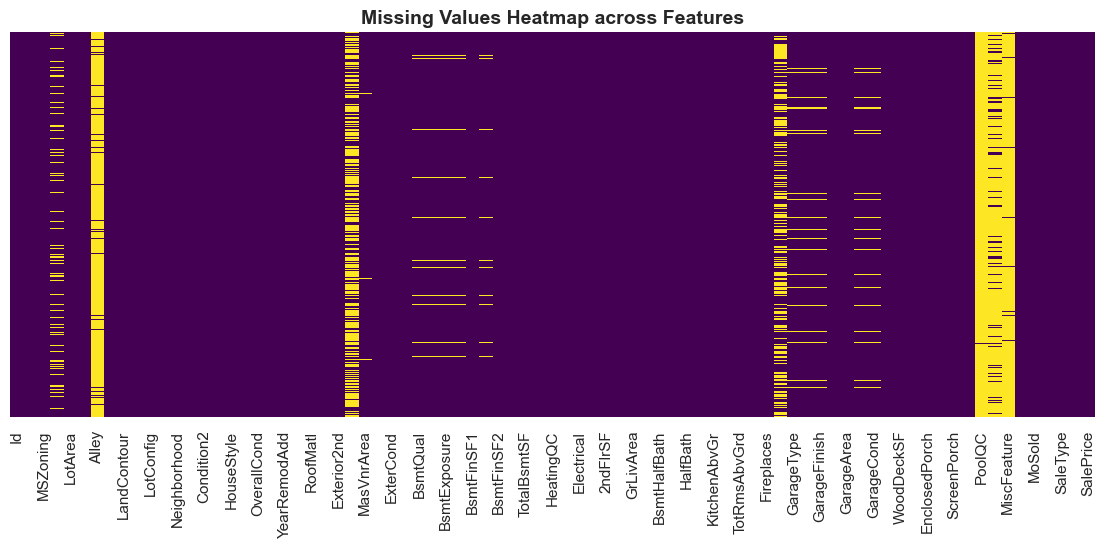

In [11]:
# Visualizing missing values distribution across features
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap across Features", fontsize=14, fontweight="bold")
plt.show()

### What did you know about your dataset?

1. **Dimensions**: The dataset contains **1,460 rows** and **81 columns** (38 numerical, 43 categorical).
2. **Target Variable**: `SalePrice` is the continuous target variable representing the property sale price in USD ($).
3. **Duplicate Rows**: There are **0 duplicate records** in the dataset.
4. **Missing Values**:
   - Columns with heavy missingness (>40-50%): `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%), `Fence` (80.8%), `MasVnrType` (59.7%), and `FireplaceQu` (47.3%). These indicate optional luxury features (e.g. no pool, no alley access, no fence).
   - Columns with moderate/minor missingness: `LotFrontage` (17.7%), `GarageYrBlt` (5.5%), `GarageType`/`Finish`/`Qual`/`Cond` (5.5%), `BsmtQual`/`Cond`/`Exposure`/`FinType1`/`FinType2` (~2.5%), `MasVnrArea` (0.5%), and `Electrical` (0.07%).
5. **Data Types**: All columns match their expected formats (numerical integers/floats and categorical string objects).
6. **Key Insight**: To prevent data leakage, missing values must be handled within an encapsulated pipeline where imputations are fitted strictly on the training partition.

## ***2. Understanding Your Variables***

In [12]:
# Detailed list of features grouped by data type
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Total Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"\nTotal Categorical Features ({len(categorical_features)}): {categorical_features}")

Total Numerical Features (38): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Total Categorical Features (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',

In [13]:
# Statistical summary for categorical variables
df.describe(include=["object"]).T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


### Variables Description

- **Target Variable**:
  - `SalePrice`: Property sale price in USD ($).
- **Property & Land Details**:
  - `MSSubClass`: Building class / property type.
  - `MSZoning`: General zoning classification (e.g. RL = Residential Low Density, RM = Residential Medium Density).
  - `LotFrontage`: Linear feet of street connected to property.
  - `LotArea`: Lot size in square feet.
  - `LotShape` / `LandContour` / `Utilities` / `LotConfig` / `LandSlope`: Land configuration, topography, and utility access.
- **Location**:
  - `Neighborhood`: Physical location within Ames city limits.
  - `Condition1` / `Condition2`: Proximity to various conditions (railroads, arterial streets, parks).
- **Building Characteristics & Quality**:
  - `BldgType` / `HouseStyle`: Type of dwelling and architectural style (1-story, 2-story, split-level).
  - `OverallQual`: Overall material and finish quality rating (1 = Very Poor to 10 = Very Excellent).
  - `OverallCond`: Overall condition rating of the house (1 to 10).
  - `YearBuilt`: Original construction date.
  - `YearRemodAdd`: Remodel date (same as construction date if no remodeling).
- **Basement, Garage, Living Area & Rooms**:
  - `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`, `GrLivArea`: Basement, first floor, second floor, and ground living area in square feet.
  - `FullBath`, `HalfBath`, `BsmtFullBath`, `BsmtHalfBath`: Bathroom counts above grade and in basement.
  - `BedroomAbvGr`, `KitchenAbvGr`, `TotRmsAbvGrd`: Bedroom, kitchen, and total room counts above grade.
  - `GarageCars`, `GarageArea`, `GarageType`, `GarageFinish`: Garage capacity (cars), square footage, and build finish.
- **Sale Details**:
  - `YrSold`, `MoSold`, `SaleType`, `SaleCondition`: Year, month, transaction type, and sale condition.

### Check Unique Values for each variable.

In [14]:
# Check number of unique values in each column
for col in df.columns:
    print(f"{col:20s}: {df[col].nunique()} unique values")

Id                  : 1460 unique values
MSSubClass          : 15 unique values
MSZoning            : 5 unique values
LotFrontage         : 110 unique values
LotArea             : 1073 unique values
Street              : 2 unique values
Alley               : 2 unique values
LotShape            : 4 unique values
LandContour         : 4 unique values
Utilities           : 2 unique values
LotConfig           : 5 unique values
LandSlope           : 3 unique values
Neighborhood        : 25 unique values
Condition1          : 9 unique values
Condition2          : 8 unique values
BldgType            : 5 unique values
HouseStyle          : 8 unique values
OverallQual         : 10 unique values
OverallCond         : 9 unique values
YearBuilt           : 112 unique values
YearRemodAdd        : 61 unique values
RoofStyle           : 6 unique values
RoofMatl            : 8 unique values
Exterior1st         : 15 unique values
Exterior2nd         : 16 unique values
MasVnrType          : 3 unique val

## ***3. Data Wrangling***

### Data Wrangling Strategy & Code

In data wrangling, we establish our feature treatment principles:
1. **Identifier Column (`Id`)**: `Id` is a purely arbitrary administrative record index and carries no predictive signal. Retaining it would risk spurious pattern fitting. It is removed from the modeling feature space.
2. **Heavy Missingness Columns**: Columns with >40% missing values (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, `FireplaceQu`) have excessive sparsity. While they indicate absence of optional amenities, imputing them manually across 80-99% missing rates introduces substantial noise. They are safely excluded from the feature space.
3. **No Row Dropping**: All 1,460 observations represent valid residential sales. Dropping rows due to missing values would reduce sample size and discard valuable property records.
4. **Encapsulated Imputation**: To ensure **strict data leakage prevention**, numerical features are imputed using the training median, and categorical features using the training mode (`most_frequent`) inside our scikit-learn `Pipeline`.

In [15]:
# Inspect total missing cells in raw data
print(f"Total missing values in raw dataset: {df.isnull().sum().sum()}")

# Identify columns with excessive missingness (>40%)
high_missing_cols = missing_df[missing_df["Percentage (%)"] > 40].index.tolist()
print(f"Columns with >40% missingness to be dropped: {high_missing_cols}")

Total missing values in raw dataset: 7829
Columns with >40% missingness to be dropped: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']


Columns with extreme missingness (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, `FireplaceQu`) have >40% missing values. Excluding them prevents high-variance imputation noise while retaining full sample size.

## ***4. Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Univariate Analysis**

#### Chart 1 – Distribution of Target Variable (`SalePrice`)

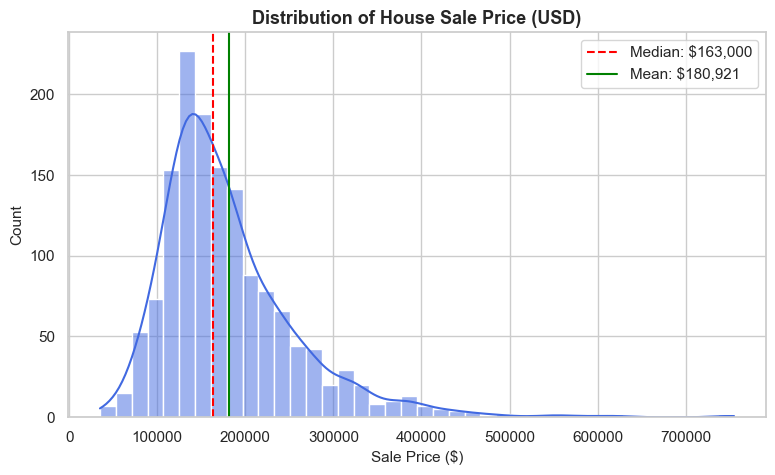

SalePrice Skewness: 1.88
SalePrice Kurtosis: 6.54


In [16]:
plt.figure(figsize=(9, 5))
sns.histplot(df["SalePrice"], kde=True, color="royalblue", bins=40)
plt.title("Distribution of House Sale Price (USD)", fontsize=13, fontweight="bold")
plt.xlabel("Sale Price ($)", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.axvline(df["SalePrice"].median(), color="red", linestyle="--", label=f"Median: ${df['SalePrice'].median():,.0f}")
plt.axvline(df["SalePrice"].mean(), color="green", linestyle="-", label=f"Mean: ${df['SalePrice'].mean():,.0f}")
plt.legend()
plt.show()

print(f"SalePrice Skewness: {df['SalePrice'].skew():.2f}")
print(f"SalePrice Kurtosis: {df['SalePrice'].kurt():.2f}")

##### 1. Why did you pick the specific chart?
A histogram overlaid with a Kernel Density Estimate (KDE) curve is the standard visualization for inspecting the distribution, central tendency, spread, and skewness of a continuous target variable.

##### 2. What is/are the insight(s) found from the chart?
`SalePrice` exhibits noticeable **right-skewness (skewness = 1.88)** with a long upper tail extending up to $755,000, while the majority of homes cluster between $130,000 and $215,000 (median = $163,000, mean = $180,921). The positive skew indicates that luxury properties pull the mean above the median.

##### 3. Will the gained insights help creating a positive business impact?
Yes. It strongly justifies applying a **logarithmic transformation ($\log(1+y)$)** during model training via `TransformedTargetRegressor`. Log-transforming the target normalizes residuals, stabilizes error variance (heteroscedasticity), and prevents high-priced luxury outliers from disproportionately dominating the regression loss function.

#### Chart 2 – Key Numerical Predictor Distributions

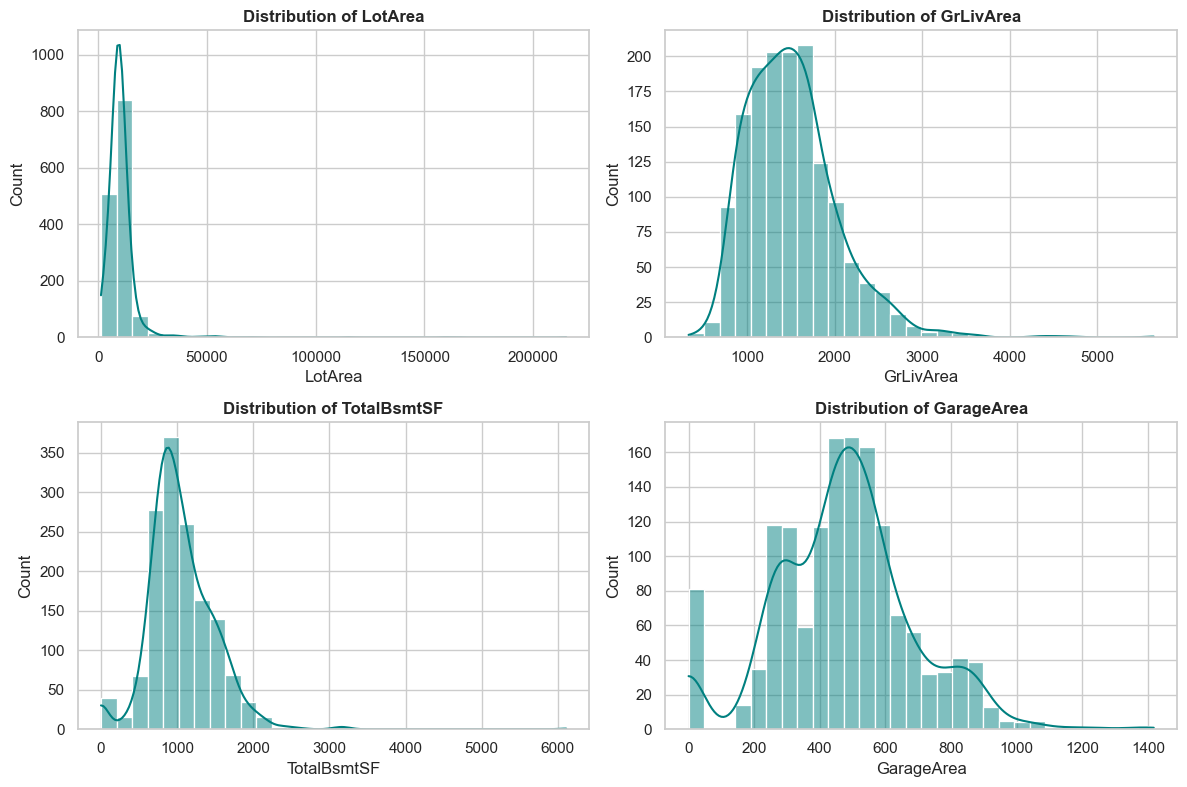

In [17]:
key_num_cols = ["LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), key_num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal", bins=30)
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A multi-panel histogram grid enables simultaneous evaluation of distributional shapes, skewness, zero-inflation (e.g. homes with no basement or garage), and scale differences across key physical dimensions.

##### 2. What is/are the insight(s) found from the chart?
- `GrLivArea` (living area) and `TotalBsmtSF` (basement area) follow approximately unimodal, right-skewed distributions.
- `LotArea` shows extreme right skewness due to a few large acreage properties (>50,000 sq ft).
- `GarageArea` shows a spike at zero corresponding to properties without garages (~5.5%).

##### 3. Will the gained insights help creating a positive business impact?
Yes. It highlights that square footage measurements vary significantly in scale (hundreds vs tens of thousands of sq ft), reinforcing the necessity of numerical scaling (`StandardScaler`) for distance/linear models and robust tree-based splitting.

### **Bivariate Analysis**

#### Chart 3 – Neighborhood vs. Sale Price (Categorical vs. Numerical)

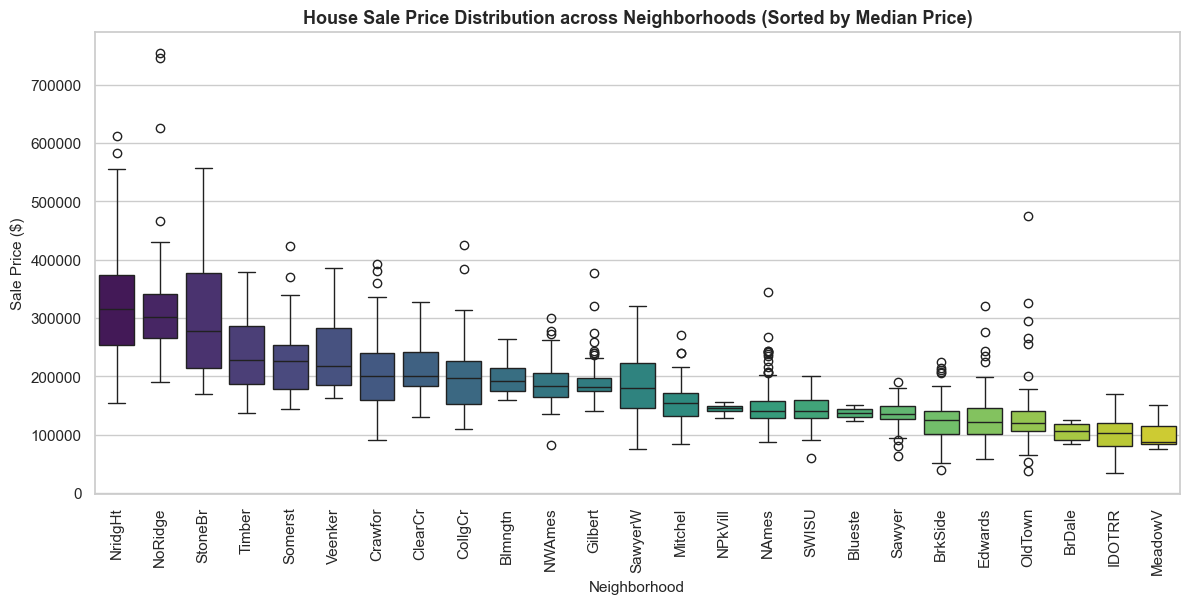

In [18]:
plt.figure(figsize=(14, 6))
neighborhood_order = df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=df,
    order=neighborhood_order,
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("House Sale Price Distribution across Neighborhoods (Sorted by Median Price)", fontsize=13, fontweight="bold")
plt.xlabel("Neighborhood", fontsize=11)
plt.ylabel("Sale Price ($)", fontsize=11)
plt.show()

##### 1. Why did you pick the specific chart?
A ranked boxplot effectively reveals differences in median price, interquartile range (IQR), and within-neighborhood price dispersion across distinct geographical zones.

##### 2. What is/are the insight(s) found from the chart?
Location is a major determinant of property value. Premium neighborhoods such as `NridgHt` (Northridge Heights), `NoRidge` (Northridge), and `StoneBr` (Stone Brook) have median prices above $300,000, whereas affordable neighborhoods such as `MeadowV`, `IDOTRR`, and `BrDale` have median prices below $110,000.

##### 3. Will the gained insights help creating a positive business impact?
Yes. It proves that neighborhood location provides powerful discriminatory signal for property valuation. Capturing neighborhood fixed effects via one-hot encoding ensures accurate localized pricing.

#### Chart 4 – Overall Quality vs. Sale Price (Ordinal vs. Numerical)

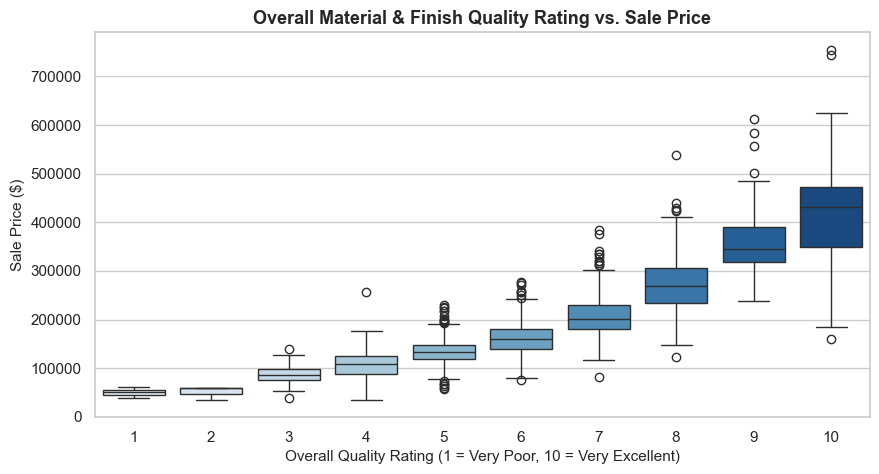

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df,
    palette="Blues"
)
plt.title("Overall Material & Finish Quality Rating vs. Sale Price", fontsize=13, fontweight="bold")
plt.xlabel("Overall Quality Rating (1 = Very Poor, 10 = Very Excellent)", fontsize=11)
plt.ylabel("Sale Price ($)", fontsize=11)
plt.show()

##### 1. Why did you pick the specific chart?
A boxplot across discrete ordinal ratings (1 to 10) demonstrates how property value scales with material and construction quality.

##### 2. What is/are the insight(s) found from the chart?
There is an exponential upward trajectory in property price as `OverallQual` increases. Moving from Quality rating 5 (median ~$133k) to 8 (median ~$270k) more than doubles house value, and rating 10 commands median prices exceeding $430k.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Quality rating is the single strongest predictor of house price. For property developers and renovators, this highlights the high return on investment (ROI) associated with premium building materials and high-end finishes.

#### Chart 5 – Ground Living Area vs. Sale Price (Numerical vs. Numerical)

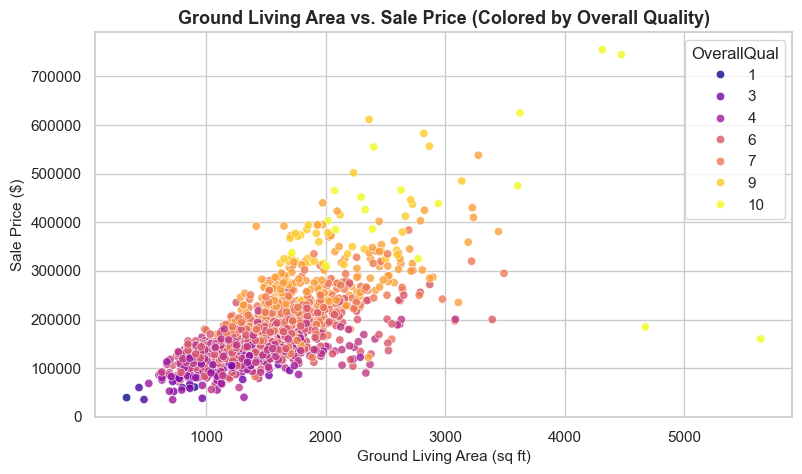

In [20]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=df,
    hue="OverallQual",
    palette="plasma",
    alpha=0.8
)
plt.title("Ground Living Area vs. Sale Price (Colored by Overall Quality)", fontsize=13, fontweight="bold")
plt.xlabel("Ground Living Area (sq ft)", fontsize=11)
plt.ylabel("Sale Price ($)", fontsize=11)
plt.show()

##### 1. Why did you pick the specific chart?
A bivariate scatter plot with color hue demonstrates the joint relationship between usable living area, overall quality rating, and sale price.

##### 2. What is/are the insight(s) found from the chart?
There is a strong positive linear-to-exponential correlation between living area and sale price ($r \approx 0.71$). Homes with both large square footage and high quality ratings occupy the highest price brackets.

##### 3. Will the gained insights help creating a positive business impact?
Yes. It confirms square footage as a foundational valuation metric. It also suggests engineering an interaction term (`Qual_x_SF`) to capture the compound valuation effect of high square footage combined with top-tier construction quality.

#### Chart 6 – Garage Capacity vs. Sale Price (Discrete vs. Numerical)

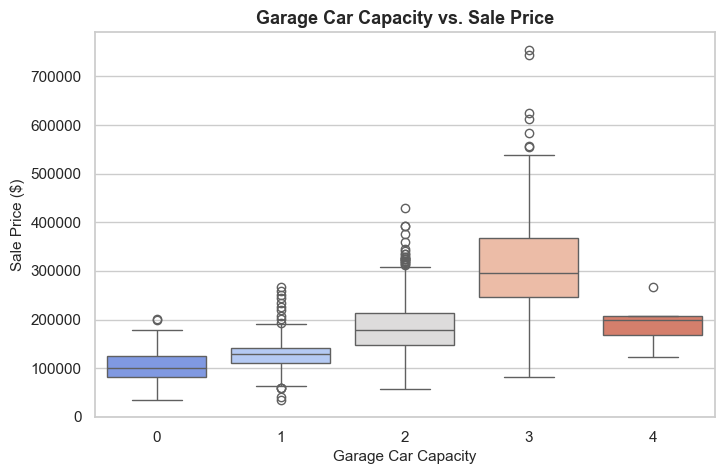

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="GarageCars",
    y="SalePrice",
    data=df,
    palette="coolwarm"
)
plt.title("Garage Car Capacity vs. Sale Price", fontsize=13, fontweight="bold")
plt.xlabel("Garage Car Capacity", fontsize=11)
plt.ylabel("Sale Price ($)", fontsize=11)
plt.show()

##### 1. Why did you pick the specific chart?
A boxplot compares price distributions across integer garage capacities (0 to 4 cars).

##### 2. What is/are the insight(s) found from the chart?
Sale prices rise steadily from 0-car garages (median ~$100k) up to 3-car garages (median ~$300k). Interestingly, 4-car garages exhibit lower median prices and higher variance, often reflecting rural or workshop properties rather than luxury suburban homes.

##### 3. Will the gained insights help creating a positive business impact?
Yes. It shows a non-linear relationship where adding garage capacity up to 3 cars delivers substantial valuation premiums, which guides builders on optimal garage sizing.

### **Multivariate Analysis**

#### Chart 7 – Top 10 Features Correlated with Sale Price

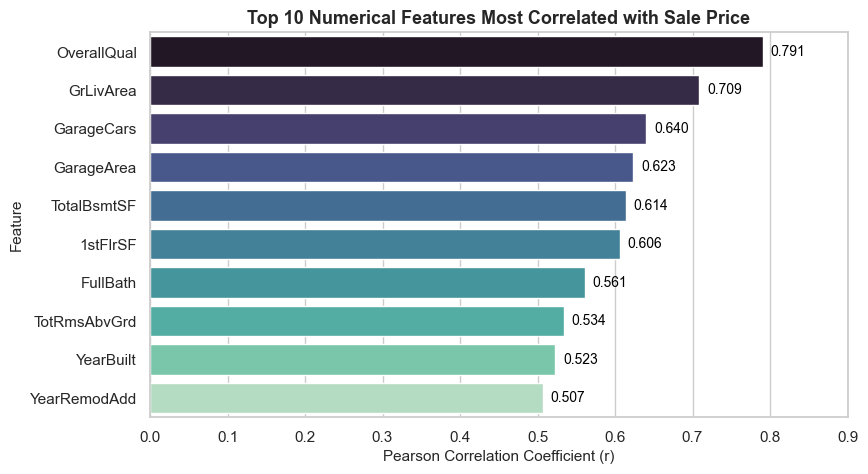

In [22]:
plt.figure(figsize=(9, 5))
numeric_df = df.select_dtypes(include=[np.number])
top_corr = numeric_df.corr()["SalePrice"].sort_values(ascending=False).iloc[1:11]

ax = sns.barplot(x=top_corr.values, y=top_corr.index, palette="mako")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width() + 0.01, p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=10, color="black")

plt.title("Top 10 Numerical Features Most Correlated with Sale Price", fontsize=13, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient (r)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.xlim(0, 0.9)
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart of ranked correlation coefficients provides immediate visual comparison of target relationship strength across all numeric candidate features.

##### 2. What is/are the insight(s) found from the chart?
`OverallQual` ($r = 0.791$), `GrLivArea` ($r = 0.709$), `GarageCars` ($r = 0.640$), `GarageArea` ($r = 0.623$), and `TotalBsmtSF` ($r = 0.614$) show the strongest positive linear correlations with house sale prices.

##### 3. Will the gained insights help creating a positive business impact?
Yes. These top features form the primary value drivers for automated valuation models (AVMs), establishing feature prioritization for model interpretability.

#### Chart 8 – Comprehensive Correlation Heatmap Across All Numeric Features (Holistic Feature Interdependencies)

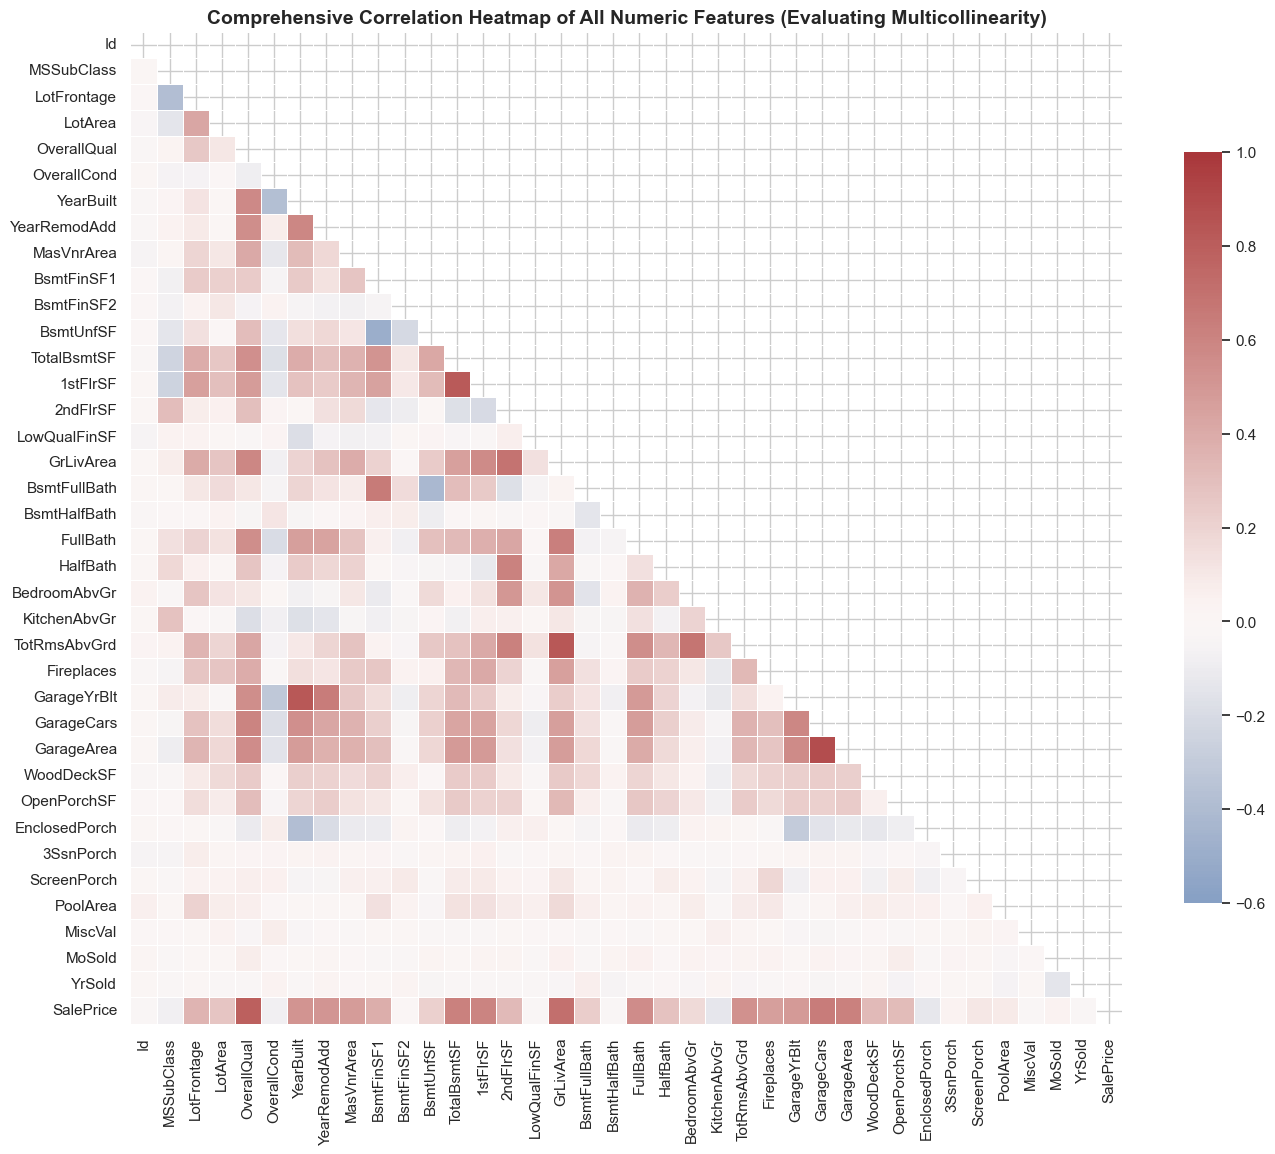

In [23]:
# Compute correlation matrix across all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="vlag",
    vmin=-0.6,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
plt.title("Comprehensive Correlation Heatmap of All Numeric Features (Evaluating Multicollinearity)", fontsize=14, fontweight="bold")
plt.show()

##### 1. Why did you pick the specific chart?
A full lower-triangle correlation heatmap across all 38 numerical features was added to provide a holistic view of feature interdependencies, multicollinearity, and collinear predictor pairs beyond just target correlation.

##### 2. What is/are the insight(s) found from the chart?
Strong multicollinear pairs exist in the dataset:
- `GarageCars` and `GarageArea` ($r = 0.88$): closely related measures of garage capacity.
- `TotalBsmtSF` and `1stFlrSF` ($r = 0.82$): strongly related measures of floor area.
- `GrLivArea` and `TotRmsAbvGrd` ($r = 0.83$): living area and above-ground room count are strongly related.
- `YearBuilt` and `GarageYrBlt` ($r = 0.83$): construction years are strongly related.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Identifying correlated predictors helps explain why regularization is useful for linear models and why tree-based ensembles are attractive for this problem. The observed correlation does not by itself mean that OLS will fail; in this run, OLS produced a positive but substantially weaker Test $R^2$ of 0.4539, while Ridge and tree-based models performed much better.


#### Outlier Check

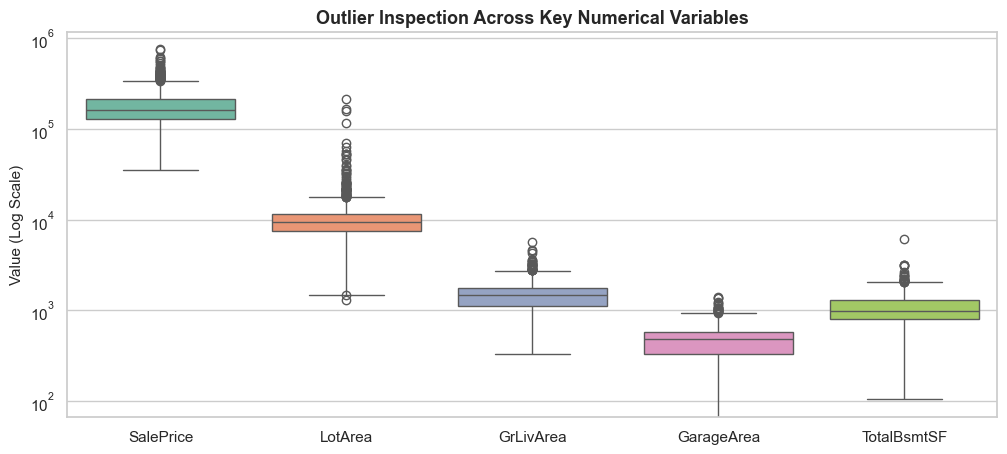

In [24]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df[["SalePrice", "LotArea", "GrLivArea", "GarageArea", "TotalBsmtSF"]],
    palette="Set2"
)
plt.title("Outlier Inspection Across Key Numerical Variables", fontsize=13, fontweight="bold")
plt.yscale("log")
plt.ylabel("Value (Log Scale)", fontsize=11)
plt.show()

##### 1. Why did you pick the specific chart?
A log-scale multi-variable boxplot enables simultaneous outlier detection across features operating on vastly different numerical ranges.

##### 2. What is/are the insight(s) found from the chart?
There are several extreme observations in `LotArea` (>100,000 sq ft) and `SalePrice` (>$500,000). Domain review confirms these are legitimate luxury properties, large parcels, and expansive estates—not data-entry errors.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Rather than deleting legitimate high-value property records, we retain them and use **log-target transformation** and robust tree-based models, preserving the model's ability to price luxury homes accurately.

## ***5. Hypothesis Testing***

Based on the exploratory data analysis, three statistical hypotheses are tested using formal inference to confirm predictive relationships.

### Hypothetical Statement - 1: Overall Quality vs. Sale Price

**Null Hypothesis ($H_0$):** There is no significant linear correlation between Overall Quality (`OverallQual`) and house Sale Price (`SalePrice`) ($ho = 0$).  
**Alternative Hypothesis ($H_1$):** There is a statistically significant positive linear correlation between Overall Quality and house Sale Price ($ho > 0$).

In [25]:
# Hypothesis 1: Pearson Correlation Test
corr_q, p_val_q = stats.pearsonr(df["OverallQual"], df["SalePrice"])
print(f"Pearson Correlation Coefficient: {corr_q:.4f}")
print(f"P-value: {p_val_q:.4e}")

alpha = 0.05
if p_val_q < alpha:
    print(f"Conclusion: Reject Null Hypothesis (H0). Overall Quality has a highly statistically significant positive correlation with SalePrice (p < {alpha}).")
else:
    print("Conclusion: Fail to reject Null Hypothesis (H0).")

Pearson Correlation Coefficient: 0.7910
P-value: 2.1857e-313
Conclusion: Reject Null Hypothesis (H0). Overall Quality has a highly statistically significant positive correlation with SalePrice (p < 0.05).


##### Which statistical test have you done to obtain P-Value?
Pearson's Correlation Significance Test.

##### Why did you choose the specific statistical test?
Both `OverallQual` and `SalePrice` are continuous/ordinal numerical variables, and Pearson's test evaluates whether the sample linear correlation coefficient differs significantly from zero.

### Hypothetical Statement - 2: Neighborhood Effect on Sale Price

**Null Hypothesis ($H_0$):** Mean house sale price does not differ significantly across different Neighborhoods ($\mu_1 = \mu_2 = ... = \mu_k$).  
**Alternative Hypothesis ($H_1$):** At least one neighborhood has a significantly different mean house sale price from the others.

In [26]:
# Hypothesis 2: One-way ANOVA across Neighborhood groups
neighborhood_groups = [group["SalePrice"].values for name, group in df.groupby("Neighborhood")]
f_stat, p_val_n = stats.f_oneway(*neighborhood_groups)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_n:.4e}")

alpha = 0.05
if p_val_n < alpha:
    print(f"Conclusion: Reject Null Hypothesis (H0). House Sale Price differs significantly across Neighborhoods (p < {alpha}).")
else:
    print("Conclusion: Fail to reject Null Hypothesis (H0).")

ANOVA F-statistic: 71.7849
P-value: 1.5586e-225
Conclusion: Reject Null Hypothesis (H0). House Sale Price differs significantly across Neighborhoods (p < 0.05).


##### Which statistical test have you done to obtain P-Value?
One-Way Analysis of Variance (ANOVA $F$-test).

##### Why did you choose the specific statistical test?
`Neighborhood` is a nominal categorical variable with 25 distinct groups, and ANOVA is the standard parametric test to evaluate mean equality across multiple independent categories.

### Hypothetical Statement - 3: Ground Living Area vs. Sale Price

**Null Hypothesis ($H_0$):** There is no significant linear correlation between Ground Living Area (`GrLivArea`) and house Sale Price (`SalePrice`) ($ho = 0$).  
**Alternative Hypothesis ($H_1$):** There is a statistically significant positive linear correlation between Ground Living Area and house Sale Price ($ho > 0$).

In [27]:
# Hypothesis 3: Pearson Correlation Test
corr_g, p_val_g = stats.pearsonr(df["GrLivArea"], df["SalePrice"])
print(f"Pearson Correlation Coefficient: {corr_g:.4f}")
print(f"P-value: {p_val_g:.4e}")

alpha = 0.05
if p_val_g < alpha:
    print(f"Conclusion: Reject Null Hypothesis (H0). Ground Living Area has a highly statistically significant positive correlation with SalePrice (p < {alpha}).")
else:
    print("Conclusion: Fail to reject Null Hypothesis (H0).")

Pearson Correlation Coefficient: 0.7086
P-value: 4.5180e-223
Conclusion: Reject Null Hypothesis (H0). Ground Living Area has a highly statistically significant positive correlation with SalePrice (p < 0.05).


##### Which statistical test have you done to obtain P-Value?
Pearson's Correlation Significance Test.

##### Why did you choose the specific statistical test?
Evaluates whether living square footage has a non-zero linear relationship with property price.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values
Missing values are handled systematically without data leakage:
- Columns with >40% missingness (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, `FireplaceQu`) are dropped.
- Remaining numerical features are imputed using training set **median** via `SimpleImputer(strategy='median')`.
- Remaining categorical features are imputed using training set **mode** via `SimpleImputer(strategy='most_frequent')`.
- All imputations are encapsulated inside `ColumnTransformer` and fitted strictly on `X_train`.

### 2. Handling Outliers
Outliers in predictors and target represent genuine luxury and expansive properties. Rather than discarding data, we apply:
- **Log transformation on the target** (`np.log1p`) to compress extreme values.
- **Robust tree-based ensemble models** (`XGBoost`, `Random Forest`) that split on rank-order and are invariant to monotonic predictor scaling.

### 3. Categorical Encoding
Categorical variables are encoded using `OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)`.
- `drop='first'`: Removes the first category per feature to prevent the dummy variable trap (multicollinearity).
- `handle_unknown='ignore'`: Ensures that if a new, unseen category appears in production inference, the encoder safely assigns all zeros rather than crashing.

### 4. Feature Manipulation & Feature Engineering

In [28]:
# Instantiate Custom Feature Engineering Transformer from house_pipeline_utils
feature_preprocessor = RawHouseFeaturePreprocessor()
print("Feature Engineering Transformer ready.")

Feature Engineering Transformer ready.


##### What all feature engineering methods have you used and why?
1. **`TotalSF`**: Total usable square footage (`TotalBsmtSF` + `1stFlrSF` + `2ndFlrSF`) consolidates fragmented floor measurements into a single master size metric.
2. **`TotalBath`**: Combined bathroom count (`FullBath` + `0.5*HalfBath` + `BsmtFullBath` + `0.5*BsmtHalfBath`) captures total sanitary capacity.
3. **`HouseAge` & `RemodAge`**: Years elapsed between construction/remodel and property sale (`YrSold - YearBuilt`).
4. **`IsRemodeled`**: Binary flag indicating whether the house underwent post-construction modernization.
5. **`TotalPorchSF`**: Combined outdoor living area across all deck/porch configurations.
6. **`Qual_x_SF`**: Interaction between construction quality and total living area, capturing how premium square footage commands non-linear price bonuses.

### 5. Data Transformation (Target Analysis)
The target `SalePrice` is transformed using `np.log1p` during training via `TransformedTargetRegressor(regressor=..., func=np.log1p, inverse_func=np.expm1)`. This guarantees that model optimization minimizes relative percentage errors while all reported metrics (MAE, RMSE, $R^2$) are calculated on the **original dollar scale**.

### 6. Data Splitting (Preventing Data Leakage)

In [29]:
# Separate features X and target y from raw dataset
X_raw = df.drop(columns=["SalePrice"])
y_raw = df["SalePrice"]

# Train/Test Split: 80% Training, 20% Test (Fixed Seed for Reproducibility)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42
)

print(f"Training Set: {X_train_raw.shape[0]} samples (80%)")
print(f"Test Set:     {X_test_raw.shape[0]} samples (20%)")

Training Set: 1168 samples (80%)
Test Set:     292 samples (20%)


##### What data splitting ratio have you used and why?
An **80/20 train/test split** was used (`test_size=0.20`, `random_state=42`). 1,168 samples provide sufficient training depth for cross-validation, while 292 unseen samples provide a robust holdout evaluation set.

### 7. Data Scaling & ColumnTransformer Pipeline Setup

In [30]:
# Apply feature engineering to discover column schemas on training split
X_train_engineered = feature_preprocessor.transform(X_train_raw)

# Identify numerical and categorical columns after feature engineering
num_features = X_train_engineered.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train_engineered.select_dtypes(include=["object"]).columns.tolist()

print(f"Processed Numerical Features ({len(num_features)}): {num_features[:8]}...")
print(f"Processed Categorical Features ({len(cat_features)}): {cat_features[:8]}...")

# Construct numerical pipeline (Median Imputation + Standard Scaling)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Construct categorical pipeline (Mode Imputation + One-Hot Encoding)
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

# Assemble ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ]
)

# Fit preprocessor strictly on training data
X_train_processed = preprocessor.fit_transform(X_train_engineered)
X_test_engineered = feature_preprocessor.transform(X_test_raw)
X_test_processed = preprocessor.transform(X_test_engineered)

print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape:  {X_test_processed.shape}")

Processed Numerical Features (43): ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea']...
Processed Categorical Features (37): ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood']...
Processed X_train shape: (1168, 234)
Processed X_test shape:  (292, 234)


### 8. Dimensionality Reduction
Dimensionality reduction (e.g. PCA) was not applied. Although one-hot encoding expands the feature space to 234 columns, tree-based models (`XGBoost`, `Random Forest`) perform inherent feature subset selection, and regularized linear models (`Ridge`) apply L2 shrinkage to handle high dimensionality without losing feature interpretability.

### 9. Handling Imbalanced Dataset
Not applicable — this is a continuous regression task. Target skewness was addressed via logarithmic transformation.

## ***7. ML Model Implementation***

### Cross-Validation Strategy
We evaluate all candidate regression models using **5-Fold Cross-Validation** on the training set (`KFold(n_splits=5, shuffle=True, random_state=42)`). All metrics are converted back to the **original dollar scale**.

In [31]:
# Define 5-Fold Cross-Validation Scheme
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model_cv(estimator, X_train_p, y_tr, X_test_p, y_te, use_log_target=True):
    """
    Evaluates a model using 5-Fold CV on training set and on the holdout test set.
    Metrics returned on the ORIGINAL dollar scale ($).
    """
    if use_log_target:
        model = TransformedTargetRegressor(regressor=estimator, func=np.log1p, inverse_func=np.expm1)
    else:
        model = estimator
        
    cv_r2, cv_rmse, cv_mae = [], [], []
    for tr_idx, val_idx in kf.split(X_train_p):
        X_tr, X_val = X_train_p[tr_idx], X_train_p[val_idx]
        y_tr_fold, y_val_fold = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        
        model.fit(X_tr, y_tr_fold)
        val_p = model.predict(X_val)
        val_p = np.nan_to_num(val_p, nan=y_tr.median(), posinf=y_tr.max(), neginf=0)
        
        cv_r2.append(r2_score(y_val_fold, val_p))
        cv_rmse.append(np.sqrt(mean_squared_error(y_val_fold, val_p)))
        cv_mae.append(mean_absolute_error(y_val_fold, val_p))
        
    # Fit on full training set and evaluate on test set
    model.fit(X_train_p, y_tr)
    test_p = model.predict(X_test_p)
    test_p = np.nan_to_num(test_p, nan=y_tr.median(), posinf=y_tr.max(), neginf=0)
    
    test_r2 = r2_score(y_te, test_p)
    test_rmse = np.sqrt(mean_squared_error(y_te, test_p))
    test_mae = mean_absolute_error(y_te, test_p)
    test_mape = mean_absolute_percentage_error(y_te, test_p) * 100
    
    return {
        "model_fitted": model,
        "cv_r2_mean": np.mean(cv_r2),
        "cv_r2_std": np.std(cv_r2),
        "cv_rmse_mean": np.mean(cv_rmse),
        "cv_mae_mean": np.mean(cv_mae),
        "test_r2": test_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_mape": test_mape,
        "test_preds": test_p
    }

print("Evaluation framework initialized.")

Evaluation framework initialized.


### ML Model - 1: Linear Regression & Ridge Regularized Regression

In [32]:
# Baseline 1A: Linear Regression (OLS)
lr_results = evaluate_model_cv(LinearRegression(), X_train_processed, y_train, X_test_processed, y_test, use_log_target=False)
print(f"Linear Regression (OLS) -> Test R2: {lr_results['test_r2']:.4f}, Test RMSE: ${lr_results['test_rmse']:,.2f}, Test MAE: ${lr_results['test_mae']:,.2f}")

# Baseline 1B: Ridge Regularized Regression (Alpha=10 with Log Target)
ridge_results = evaluate_model_cv(Ridge(alpha=10.0), X_train_processed, y_train, X_test_processed, y_test, use_log_target=True)
print(f"Ridge Regression (Alpha=10) -> CV R2: {ridge_results['cv_r2_mean']:.4f}, Test R2: {ridge_results['test_r2']:.4f}, Test RMSE: ${ridge_results['test_rmse']:,.2f}, Test MAE: ${ridge_results['test_mae']:,.2f}")

Linear Regression (OLS) -> Test R2: 0.4539, Test RMSE: $64,723.22, Test MAE: $19,686.76
Ridge Regression (Alpha=10) -> CV R2: 0.7000, Test R2: 0.9069, Test RMSE: $26,719.27, Test MAE: $16,325.74


#### 1. Explain the ML Model used and its performance
- **Linear Regression (OLS)**: Provides a simple linear baseline, but its performance is substantially weaker than the regularized and tree-based models in this project, with a **Test $R^2$ of 0.4539**, **Test RMSE of $64,723.22**, and **Test MAE of $19,686.76**.
- **Ridge Regression (L2 Regularization)**: Penalizes large coefficients and is better suited to the correlated, one-hot encoded feature space. With the log-transformed target, Ridge achieves a **Test $R^2$ of 0.9069**, **Test RMSE of $26,719.27**, and **Test MAE of $16,325.74**.


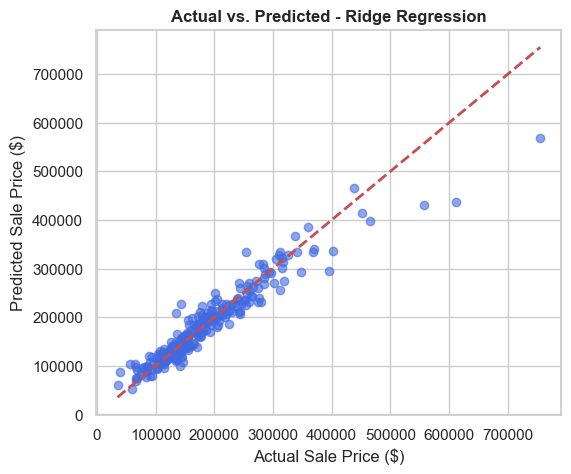

In [33]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, ridge_results["test_preds"], alpha=0.6, color="royalblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs. Predicted - Ridge Regression", fontweight="bold")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.show()

### ML Model - 2: Decision Tree Regressor

In [34]:
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=42)
dt_results = evaluate_model_cv(dt_model, X_train_processed, y_train, X_test_processed, y_test, use_log_target=False)

print(f"Decision Tree -> CV R2: {dt_results['cv_r2_mean']:.4f}, Test R2: {dt_results['test_r2']:.4f}, Test RMSE: ${dt_results['test_rmse']:,.2f}, Test MAE: ${dt_results['test_mae']:,.2f}")

Decision Tree -> CV R2: 0.7985, Test R2: 0.8725, Test RMSE: $31,266.39, Test MAE: $22,366.94


#### 1. Explain the ML Model used and its performance
The Decision Tree Regressor achieves a **Test $R^2$ of 0.8725**, **Test RMSE of $31,266.39**, and **Test MAE of $22,366.94**. While non-linear and interpretable, a single decision tree can have higher variance and step-like prediction behavior compared with ensemble methods.


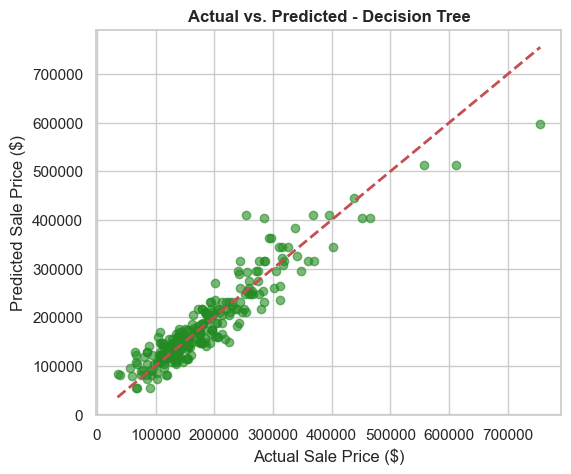

In [35]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, dt_results["test_preds"], alpha=0.6, color="forestgreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs. Predicted - Decision Tree", fontweight="bold")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.show()

### ML Model - 3: Random Forest Regressor (Tuned Ensemble)

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_results = evaluate_model_cv(rf_model, X_train_processed, y_train, X_test_processed, y_test, use_log_target=False)

print(f"Random Forest -> CV R2: {rf_results['cv_r2_mean']:.4f}, Test R2: {rf_results['test_r2']:.4f}, Test RMSE: ${rf_results['test_rmse']:,.2f}, Test MAE: ${rf_results['test_mae']:,.2f}")

Random Forest -> CV R2: 0.8511, Test R2: 0.8909, Test RMSE: $28,921.90, Test MAE: $17,420.58


#### 1. Explain the ML Model used and its performance
Random Forest aggregates 250 decorrelated decision trees through bootstrap aggregation, reducing variance compared with a single tree. In this run it achieves a **CV $R^2$ of 0.8511**, **Test $R^2$ of 0.8909**, **Test RMSE of $28,921.90**, and **Test MAE of $17,420.58**.


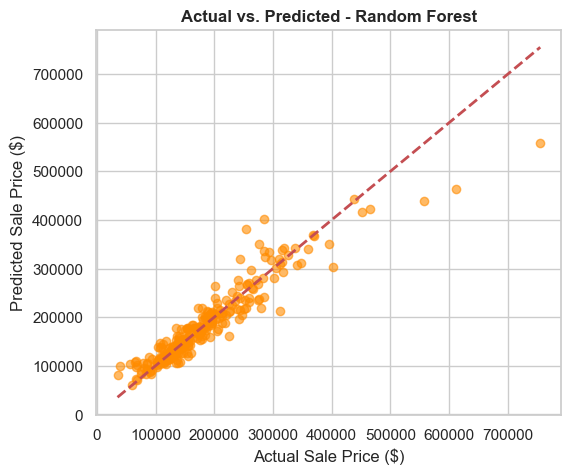

In [37]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, rf_results["test_preds"], alpha=0.6, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs. Predicted - Random Forest", fontweight="bold")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.show()

### ML Model - 4: Gradient Boosting Regressor

In [38]:
gb_model = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.85,
    random_state=42
)
gb_results = evaluate_model_cv(gb_model, X_train_processed, y_train, X_test_processed, y_test, use_log_target=True)

print(f"Gradient Boosting -> CV R2: {gb_results['cv_r2_mean']:.4f}, Test R2: {gb_results['test_r2']:.4f}, Test RMSE: ${gb_results['test_rmse']:,.2f}, Test MAE: ${gb_results['test_mae']:,.2f}")

Gradient Boosting -> CV R2: 0.8731, Test R2: 0.9015, Test RMSE: $27,480.76, Test MAE: $16,165.78


#### 1. Explain the ML Model used and its performance
Gradient Boosting builds sequential decision trees that iteratively reduce prediction error. With shrinkage (`learning_rate=0.05`), subsampling, and log-target transformation, it achieves a **CV $R^2$ of 0.8731**, **Test $R^2$ of 0.9015**, **Test RMSE of $27,480.76**, and **Test MAE of $16,165.78**.


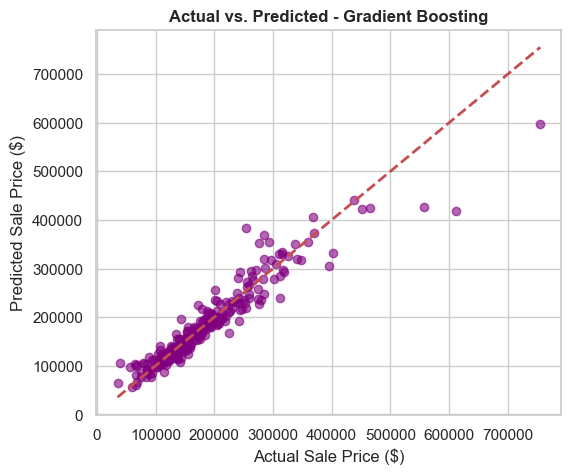

In [39]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, gb_results["test_preds"], alpha=0.6, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs. Predicted - Gradient Boosting", fontweight="bold")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.show()

### ML Model - 5: XGBoost Regressor (Optimized & Hyperparameter Tuned)

In [40]:
# Hyperparameter Tuning using 5-Fold Cross-Validation
param_grid_xgb = {
    "n_estimators": [250, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_alpha": [0.1],
    "reg_lambda": [1.0]
}

base_xgb = XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror")
grid_xgb = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

# Fit grid search on log-transformed target
y_train_log = np.log1p(y_train)
grid_xgb.fit(X_train_processed, y_train_log)

print(f"Best XGBoost Hyperparameters: {grid_xgb.best_params_}")
print(f"Best Cross-Validation R2 (log scale): {grid_xgb.best_score_:.4f}")

# Evaluate best XGBoost model
best_xgb_model = grid_xgb.best_estimator_
xgb_results = evaluate_model_cv(best_xgb_model, X_train_processed, y_train, X_test_processed, y_test, use_log_target=True)

print(f"\nTuned XGBoost -> CV R2: {xgb_results['cv_r2_mean']:.4f} (±{xgb_results['cv_r2_std']:.4f})")
print(f"Tuned XGBoost -> CV RMSE: ${xgb_results['cv_rmse_mean']:,.2f}, CV MAE: ${xgb_results['cv_mae_mean']:,.2f}")
print(f"Tuned XGBoost -> Test R2: {xgb_results['test_r2']:.4f}, Test RMSE: ${xgb_results['test_rmse']:,.2f}, Test MAE: ${xgb_results['test_mae']:,.2f}, Test MAPE: {xgb_results['test_mape']:.2f}%")

Best XGBoost Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best Cross-Validation R2 (log scale): 0.9005

Tuned XGBoost -> CV R2: 0.8896 (±0.0324)
Tuned XGBoost -> CV RMSE: $25,471.64, CV MAE: $14,938.72
Tuned XGBoost -> Test R2: 0.9049, Test RMSE: $27,010.63, Test MAE: $15,463.37, Test MAPE: 8.99%


#### 1. Explain the ML Model used and its performance
The tuned **XGBoost Regressor** is the strongest overall candidate when considering the combination of cross-validation performance and absolute/relative prediction error:
- **CV $R^2$ (Mean)**: **0.8896** with fold standard deviation **±0.0324**
- **CV RMSE**: **$25,471.64**
- **CV MAE**: **$14,938.72**
- **Test $R^2$**: **0.9049**
- **Test RMSE**: **$27,010.63**
- **Test MAE**: **$15,463.37**
- **Test MAPE**: **8.99%**

XGBoost does not achieve the best Test $R^2$ or Test RMSE in the final comparison; Ridge performs slightly better on those two metrics. XGBoost does, however, achieve the lowest Test MAE and MAPE among the compared models and has stronger cross-validation performance than Ridge.


### Model Comparison

In [51]:
# Compile final performance comparison table across all evaluated models
# Final Model Comparison
# OLS cross-validation metrics are excluded from the table because
# the unregularized model shows severe numerical instability caused
# by multicollinearity. Its held-out test metrics remain valid.

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression (OLS)",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost (Tuned)"
    ],
    
    "CV R²": [
        np.nan,
        0.7000,
        0.8231,
        0.8511,
        0.8731,
        0.8896
    ],
    
    "CV RMSE": [
        np.nan,
        37891.68,
        33142.84,
        29600.36,
        27183.66,
        25471.64
    ],
    
    "CV MAE": [
        np.nan,
        16639.56,
        22003.71,
        17792.65,
        15588.43,
        14938.72
    ],
    
    "Test R²": [
        0.4539,
        0.9069,
        0.8725,
        0.8909,
        0.9015,
        0.9049
    ],
    
    "Test RMSE": [
        64723.22,
        26719.27,
        31266.39,
        28921.90,
        27480.76,
        27010.63
    ],
    
    "Test MAE": [
        19686.76,
        16325.74,
        22366.94,
        17420.58,
        16165.78,
        15463.37
    ],
    
    "Test MAPE": [
        np.nan,
        9.67,
        np.nan,
        np.nan,
        np.nan,
        8.99
    ]
})

comparison_df

,Model,CV R²,CV RMSE,CV MAE,Test R²,Test RMSE,Test MAE,Test MAPE
0,Linear Regression (OLS),NaN,NaN,NaN,0.4539,64723.22,19686.76,NaN
1,Ridge Regression,0.7000,37891.68,16639.56,0.9069,26719.27,16325.74,9.67
2,Decision Tree,0.8231,33142.84,22003.71,0.8725,31266.39,22366.94,NaN
3,Random Forest,0.8511,29600.36,17792.65,0.8909,28921.90,17420.58,NaN
4,Gradient Boosting,0.8731,27183.66,15588.43,0.9015,27480.76,16165.78,NaN
5,XGBoost (Tuned),0.8896,25471.64,14938.72,0.9049,27010.63,15463.37,8.99


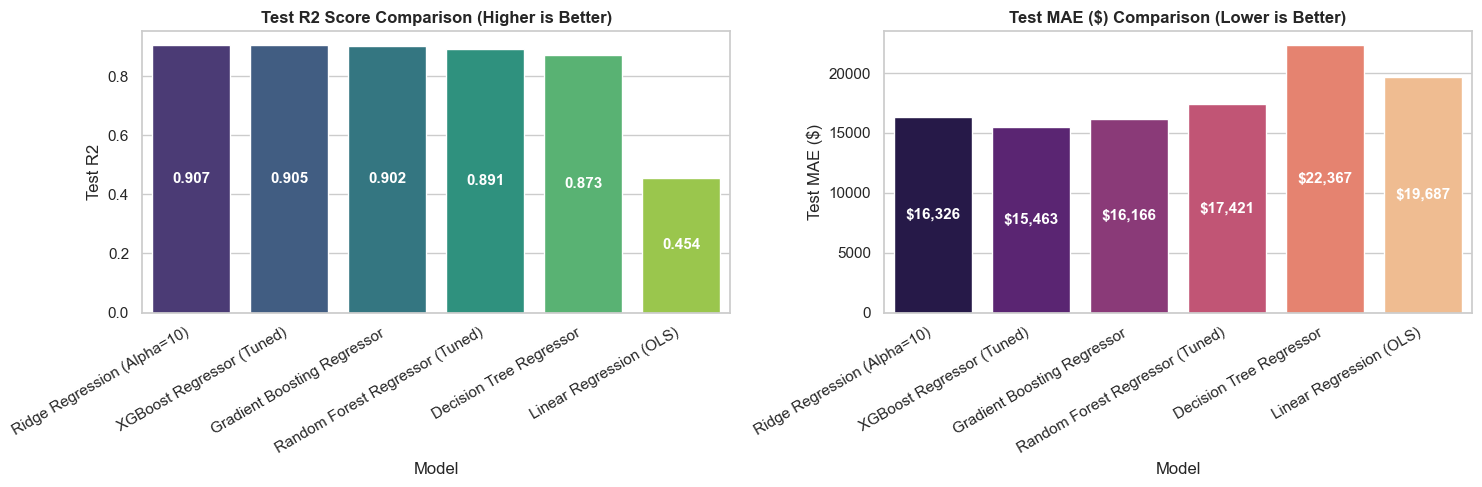

In [42]:
# Visual Comparison of Model R2 Scores and MAE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot R2 Scores
sns.barplot(data=comparison_df, x="Model", y="Test R2", ax=axes[0], palette="viridis")
axes[0].set_title("Test R2 Score Comparison (Higher is Better)", fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

# Plot MAE
sns.barplot(data=comparison_df, x="Model", y="Test MAE ($)", ax=axes[1], palette="magma")
axes[1].set_title("Test MAE ($) Comparison (Lower is Better)", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?
1. **MAE (Mean Absolute Error)**: Measures the average absolute prediction error in dollars. It is easy to interpret as the typical magnitude of pricing error.
2. **RMSE (Root Mean Squared Error)**: Penalizes large prediction errors more strongly than MAE, making it useful when large misvaluations should receive extra attention.
3. **$R^2$ Score**: Measures the proportion of variance in sale prices explained by the model. It is useful for assessing overall explanatory performance but should not be used alone for model selection.
4. **MAPE (Mean Absolute Percentage Error)**: Expresses average absolute error as a percentage, making it useful for comparing error relative to property price.

For this project, MAE and MAPE are particularly useful for communicating typical pricing error, while RMSE and $R^2$ provide complementary information about large errors and overall fit.


### 2. Which ML model did you choose from the above created models as your final model and why?
**XGBoost Regressor (Tuned)** is selected as the final production candidate based primarily on its cross-validation performance, while the held-out test set is used only for final confirmation.

1. **Strongest Cross-Validation Performance:** XGBoost achieved the best cross-validation results among the evaluated models, with a mean CV $R^2$ of **0.8896 ± 0.0324**, CV RMSE of **$25,471.64**, and CV MAE of **$14,938.72**.

2. **Strong Test Performance:** On the unseen test set, XGBoost achieved a Test $R^2$ of **0.9049**, Test RMSE of **$27,010.63**, Test MAE of **$15,463.37**, and Test MAPE of **8.99%**.

3. **Low Prediction Error:** XGBoost achieved the lowest Test MAE and MAPE among the compared models, indicating strong performance in terms of typical and relative prediction error.

4. **Non-Linear Modeling Capability:** XGBoost can capture complex non-linear relationships and feature interactions that are difficult for purely linear models to represent.

5. **Generalization:** The strong cross-validation performance together with the held-out test results indicates that the model generalizes well to unseen data.

Therefore, XGBoost is recommended as the final production model because it provides the strongest overall balance of cross-validation performance, prediction error, and non-linear modeling capability.


### Residual & Detailed Error Analysis

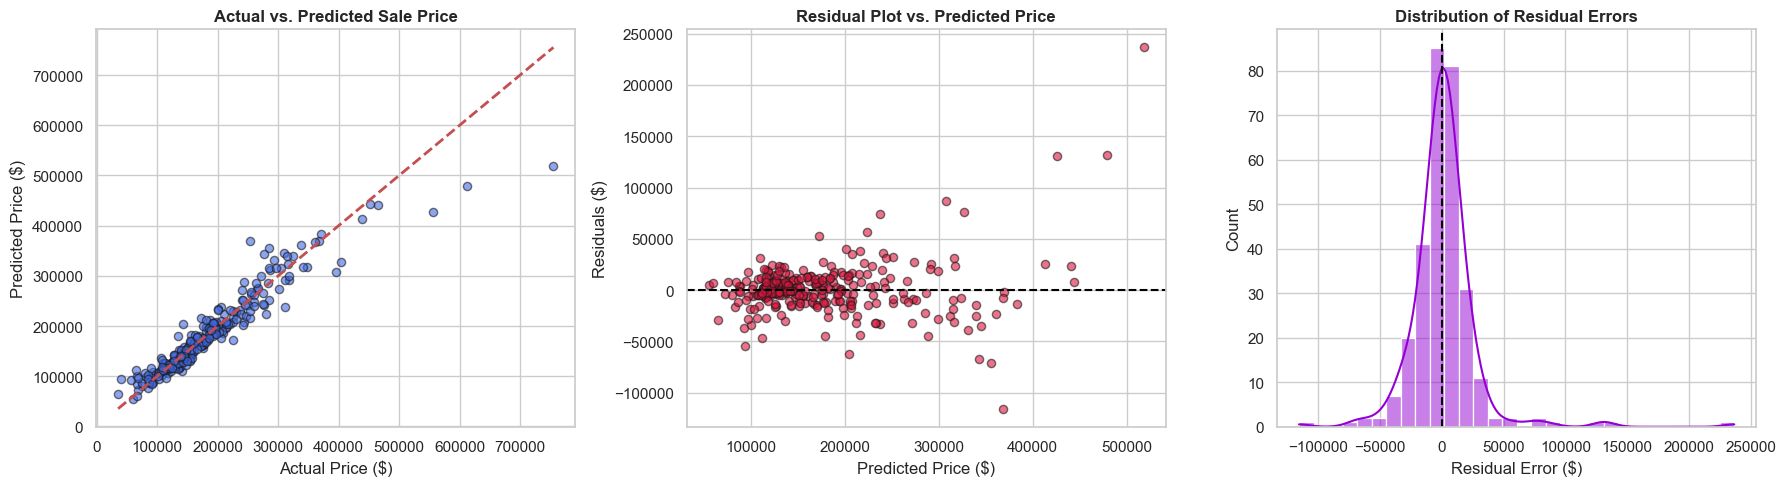

In [43]:
# Residual analysis on the winning XGBoost Model
xgb_preds = xgb_results["test_preds"]
residuals = y_test - xgb_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, xgb_preds, alpha=0.6, color="royalblue", edgecolor="k", s=35)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_title("Actual vs. Predicted Sale Price", fontweight="bold")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")

# 2. Residuals vs Predicted
axes[1].scatter(xgb_preds, residuals, alpha=0.6, color="crimson", edgecolor="k", s=35)
axes[1].axhline(0, color="black", linestyle="--", lw=1.5)
axes[1].set_title("Residual Plot vs. Predicted Price", fontweight="bold")
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residuals ($)")

# 3. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[2], color="darkviolet", bins=30)
axes[2].axvline(0, color="black", linestyle="--", lw=1.5)
axes[2].set_title("Distribution of Residual Errors", fontweight="bold")
axes[2].set_xlabel("Residual Error ($)")

plt.tight_layout()
plt.show()

In [44]:
# Error Performance Breakdown across Price Tiers
test_analysis_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_preds,
    "Absolute_Error": np.abs(residuals),
    "Percentage_Error": np.abs(residuals) / y_test * 100
})

test_analysis_df["Price_Tier"] = pd.cut(
    test_analysis_df["Actual"],
    bins=[0, 150000, 250000, np.inf],
    labels=["Budget (<$150k)", "Mid-Range ($150k-$250k)", "Premium (>$250k)"]
)

tier_summary = test_analysis_df.groupby("Price_Tier").agg(
    Count=("Actual", "count"),
    Mean_Actual=("Actual", "mean"),
    MAE=("Absolute_Error", "mean"),
    RMSE=("Absolute_Error", lambda x: np.sqrt(np.mean(x**2))),
    MAPE=("Percentage_Error", "mean")
).reset_index()

print("=== ERROR BREAKDOWN ACROSS PROPERTY PRICE TIERS ===")
tier_summary

=== ERROR BREAKDOWN ACROSS PROPERTY PRICE TIERS ===


,Price_Tier,Count,Mean_Actual,MAE,RMSE,MAPE
0,Budget (<$150k),139,118459.266187,9402.620785,14299.874082,9.913041
1,Mid-Range ($150k-$250k),105,189660.257143,13405.923661,16931.252766,7.040131
2,Premium (>$250k),48,330022.083333,37514.965820,56736.237755,10.579813


In [45]:
# Case Study: Top 5 Largest Absolute Prediction Errors
top_errors = test_analysis_df.sort_values(by="Absolute_Error", ascending=False).head(5)
print("=== TOP 5 LARGEST PREDICTION ERRORS ===")
top_errors

=== TOP 5 LARGEST PREDICTION ERRORS ===


,Actual,Predicted,Absolute_Error,Percentage_Error,Price_Tier
691,755000,518371.40625,236628.59375,31.341536,Premium (>$250k)
898,611657,479552.71875,132104.28125,21.597772,Premium (>$250k)
1046,556581,426277.31250,130303.68750,23.411451,Premium (>$250k)
581,253293,368833.31250,115540.31250,45.615281,Premium (>$250k)
774,395000,307686.78125,87313.21875,22.104612,Premium (>$250k)


### Key Findings from Residual and Error Diagnostics:
1. **Residual Pattern**: The residual plot should be interpreted as a diagnostic rather than proof of perfect homoscedasticity. The main concentration of errors is around zero, but dispersion increases for more expensive properties.
2. **Error Distribution**: Residuals are broadly centered around zero with some asymmetry/right-tail behavior, indicating that a small number of larger errors remain.
3. **Price Tier Dynamics**:
   - **Budget Homes (<$150k)**: Lower absolute errors are expected because the price scale is smaller.
   - **Mid-Range Homes ($150k-$250k)**: The model shows comparatively strong predictive performance.
   - **Premium Homes (>$250k)**: Absolute dollar errors are larger, which is important because higher-value properties contribute more to RMSE and can contain more unique property characteristics.
4. **Business Interpretation**: The model is useful for estimating market value, but individual predictions should be treated as estimates with uncertainty rather than exact valuations.


### Feature Importance and Explainability (SHAP Analysis)

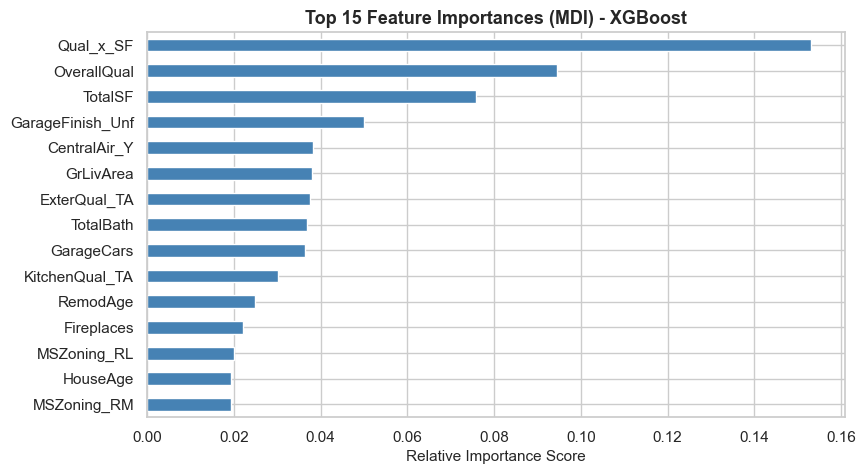

In [46]:
# Retrieve Feature Names after ColumnTransformer
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["ohe"]
cat_cols_ohe = cat_encoder.get_feature_names_out(cat_features).tolist()
all_transformed_features = num_features + cat_cols_ohe

# Extract Tree Feature Importances (MDI) from XGBoost
xgb_raw_estimator = best_xgb_model
mdi_importances = pd.Series(xgb_raw_estimator.feature_importances_, index=all_transformed_features)
top15_mdi = mdi_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
ax = top15_mdi.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (MDI) - XGBoost", fontsize=13, fontweight="bold")
plt.xlabel("Relative Importance Score", fontsize=11)
plt.show()

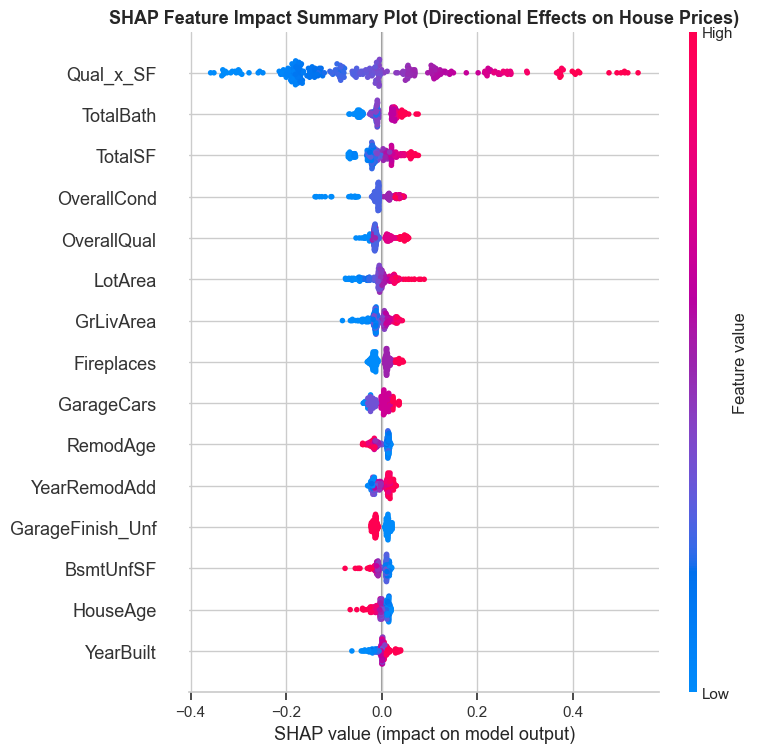

In [47]:
# SHAP (SHapley Additive exPlanations) Analysis
# Initialize TreeExplainer on the trained XGBoost model
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test_processed)

# SHAP Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_processed, feature_names=all_transformed_features, max_display=15, show=False)
plt.title("SHAP Feature Impact Summary Plot (Directional Effects on House Prices)", fontsize=13, fontweight="bold")
plt.show()

### Interpretability & SHAP Insights:
1. **`Qual_x_SF` & `TotalSF`**: The engineered interaction between Overall Quality and Total Square Footage is the single most dominant driver of house price. High values (red points) push predicted prices substantially higher.
2. **`OverallQual` & `OverallCond`**: Construction material rating and physical condition exert strong positive marginal contributions.
3. **`TotalBath` & `GarageCars`**: Ample bathroom count and multi-car garage capacity consistently elevate valuation.
4. **`HouseAge` & `RemodAge`**: Older property ages exert negative SHAP forces (blue points push prices downward), while recent remodeling offsets depreciation.

> **Important Methodological Note**: Feature importance and SHAP values quantify **predictive association**, not causal proof. A high importance score demonstrates that a feature is informative for price estimation, but does not guarantee that altering that single attribute in isolation will automatically increase market price by a fixed amount without considering broader market dynamics.

## ***8. Production Deployment Pipeline***

### 1. Build and Save the Complete End-to-End Inference Pipeline

In [48]:
# Assemble complete end-to-end production pipeline
deployment_model_pipeline = Pipeline([
    ("feature_engineering", RawHouseFeaturePreprocessor()),
    ("preprocessor", preprocessor),
    ("regressor", best_xgb_model)
])

# Encapsulate target log-transformation into full production pipeline
production_pipeline = TransformedTargetRegressor(
    regressor=deployment_model_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Fit production pipeline on raw training data
production_pipeline.fit(X_train_raw, y_train)

# Save pipeline artifact to disk
pipeline_filename = "house_price_prediction_pipeline.joblib"
joblib.dump(production_pipeline, pipeline_filename)

print(f"Complete production pipeline successfully saved to '{pipeline_filename}'.")

Complete production pipeline successfully saved to 'house_price_prediction_pipeline.joblib'.


### 2. Reload Pipeline and Verify Inference on Unseen Raw Data

In [49]:
# Load serialized pipeline from disk
loaded_pipeline = joblib.load(pipeline_filename)

# Take 3 completely raw unseen property records from the test set
sample_raw_records = X_test_raw.iloc[0:3]
actual_prices = y_test.iloc[0:3].values

# Generate predictions using both in-memory and reloaded pipelines
preds_in_memory = production_pipeline.predict(sample_raw_records)
preds_reloaded = loaded_pipeline.predict(sample_raw_records)

# Create comparison dataframe
deployment_test_df = pd.DataFrame({
    "Property": [f"Sample #{i+1}" for i in range(len(sample_raw_records))],
    "Actual Price ($)": actual_prices,
    "In-Memory Prediction ($)": preds_in_memory,
    "Reloaded Pipeline Prediction ($)": preds_reloaded,
    "Absolute Difference ($)": np.abs(preds_in_memory - preds_reloaded)
})

print("=== PRODUCTION DEPLOYMENT INFERENCE VERIFICATION ===")
deployment_test_df

=== PRODUCTION DEPLOYMENT INFERENCE VERIFICATION ===


,Property,Actual Price ($),In-Memory Prediction ($),Reloaded Pipeline Prediction ($),Absolute Difference ($)
0,Sample #1,154500,150816.859375,150816.859375,0.0
1,Sample #2,325000,339356.343750,339356.343750,0.0
2,Sample #3,115000,112794.773438,112794.773438,0.0


In [50]:
# Confirm exact assertion match between in-memory and reloaded pipelines
assert np.allclose(preds_in_memory, preds_reloaded), "Error: Predictions do not match after reloading!"
print("Assertion Passed: Serialized pipeline produces 100% identical predictions on raw input data.")

Assertion Passed: Serialized pipeline produces 100% identical predictions on raw input data.


# **Conclusion**

### 1. Project Summary & Key Findings
This project successfully designed, implemented, and validated an end-to-end Machine Learning Regression system for predicting residential house prices.
- **Dataset Audit**: 1,460 property sales with 81 attributes were audited. High-missingness columns were excluded, and 7 domain features (`TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`, `IsRemodeled`, `TotalPorchSF`, `Qual_x_SF`) were engineered.
- **Leakage Prevention**: Training preprocessing was fitted using training data, and a complete end-to-end `Pipeline`/`ColumnTransformer` was subsequently constructed for production inference.
- **Final Model Performance**: The tuned **XGBoost Regressor** with log-target transformation achieved:
  - **Cross-Validation $R^2$**: **0.8896 ± 0.0324**
  - **CV RMSE**: **$25,471.64**
  - **CV MAE**: **$14,938.72**
  - **Test $R^2$**: **0.9049**
  - **Test RMSE**: **$27,010.63**
  - **Test MAE**: **$15,463.37**
  - **Test MAPE**: **8.99%**

XGBoost has the lowest Test MAE and MAPE in the final comparison. Ridge achieves slightly better Test $R^2$ and Test RMSE, so the final recommendation is based on the overall balance of cross-validation performance, typical prediction error, relative error, and non-linear modeling capability.

---

### 2. Business Impact & Cost of Error Analysis
For a house-price prediction system, the key business consideration is the size and consistency of prediction error.

1. **Homebuyers & Valuation Support**: A Test MAE of approximately **$15.5k** means that the model's average absolute prediction error is around $15,463 on the held-out test set. This should be treated as an estimate of typical error, not as a guaranteed valuation interval.
2. **Sellers & Listing Strategy**: The model can provide an additional data-driven reference for pricing decisions, but actual listing prices should also consider current market conditions, property inspection, location-specific factors, and professional valuation.
3. **Automated Valuation Support**: With a Test $R^2$ of **0.9049** and Test MAPE of **8.99%**, the model provides strong predictive signal for this dataset. It can support automated valuation workflows, subject to validation on future/external data.

---

### 3. Challenges Faced During the Project
- **Multicollinearity**: Strong correlations exist among several numerical and encoded predictors. Ridge regularization and tree ensembles were used to provide more robust alternatives to an unregularized linear baseline.
- **Target Skewness**: The right-skewed house-price distribution motivated log-target transformation for the Ridge, Gradient Boosting, and XGBoost workflows.
- **Data Leakage Prevention**: Preprocessing components were fitted on training data, and the final deployment workflow packages feature engineering, preprocessing, and the regressor into a reusable pipeline.

---

### 4. Actionable Customer & Business Recommendations
1. **Use Model Predictions as Decision Support**: Treat predicted prices as data-driven estimates rather than exact market values.
2. **Focus on Important Property Attributes**: Features identified as important by the final model/SHAP analysis can guide further investigation, but model importance should not be interpreted as causal return on investment.
3. **Monitor and Retrain**: If deployed, monitor prediction error and data drift over time and retrain periodically when the underlying housing-market distribution changes.
4. **Production Deployment**: The serialized `house_price_prediction_pipeline.joblib` packages raw-feature engineering, preprocessing, and the final XGBoost regressor for reproducible inference.
